# 01 — Data Preparation
## REVER Logistics Cost & Revenue Analysis — 2025

This notebook loads, cleans, and joins all raw data sources into a single analysis-ready table.  
It must be run before any other notebook. Outputs are saved to `../processed/`.

**Sources:**
- REVER invoiced logistics (what REVER charges merchants)
- REVER invoiced adjustments (extra charges passed through to merchants)
- Carrier invoices: Correos, Correos Express, UPS, GLS, BRT

**Key output:** `merged.parquet` — one row per shipment with both revenue (REVER side) and cost (carrier side).

In [1]:
import warnings
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Paths ────────────────────────────────────────────────────────────────────
try:
    ROOT = Path(__vsc_ipynb_file__).parent.parent
except NameError:
    ROOT = Path("..").resolve()
REVER_DIR  = ROOT / "07.08.08.01.02 REVER 2025"
CARRIER_DIR= ROOT / "07.08.08.01.01 Carriers 2025"
PROCESSED  = ROOT / "processed"
PROCESSED.mkdir(exist_ok=True)

# ── Global visual style (applied to every plot in every notebook) ─────────────
PALETTE = {
    "primary"   : "#2C5F8A",
    "positive"  : "#2A9D8F",
    "negative"  : "#E63946",
    "neutral"   : "#ADB5BD",
    "accent"    : "#F4A261",
    "bg"        : "#FFFFFF",
    "grid"      : "#F0F0F0",
}

CARRIER_COLORS = {
    "Correos"         : "#F4A261",
    "Correos Express" : "#E63946",
    "UPS"             : "#8B5E3C",
    "GLS"             : "#2A9D8F",
    "BRT"             : "#457B9D",
}

plt.rcParams.update({
    "figure.facecolor"  : PALETTE["bg"],
    "axes.facecolor"    : PALETTE["bg"],
    "axes.grid"         : True,
    "grid.color"        : PALETTE["grid"],
    "grid.linewidth"    : 0.8,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.spines.left"  : True,
    "axes.spines.bottom": True,
    "axes.edgecolor"    : "#CCCCCC",
    "font.family"       : "sans-serif",
    "font.size"         : 11,
    "axes.titlesize"    : 14,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 11,
    "xtick.labelsize"   : 10,
    "ytick.labelsize"   : 10,
    "legend.frameon"    : False,
    "legend.fontsize"   : 10,
    "figure.dpi"        : 110,
    "figure.figsize"    : (14, 5),
})

FIG_W, FIG_H = 14, 5

print("✓ Libraries loaded | Style configured | Paths set")
print(f"  REVER dir  : {REVER_DIR}")
print(f"  Carrier dir: {CARRIER_DIR}")
print(f"  Processed  : {PROCESSED}")

✓ Libraries loaded | Style configured | Paths set
  REVER dir  : /mnt/c/Users/MOLO/Downloads/test_rever_agent/data_analisis/07.08.08.01.02 REVER 2025
  Carrier dir: /mnt/c/Users/MOLO/Downloads/test_rever_agent/data_analisis/07.08.08.01.01 Carriers 2025
  Processed  : /mnt/c/Users/MOLO/Downloads/test_rever_agent/data_analisis/processed


---
## Section 1 — REVER Data

Load what REVER charges merchants (`invoiced`) and the extra adjustment charges (`adjustments`).  
`invoicing_period` is normalized to `YYYY-MM` format for easy grouping.

In [2]:
# ── REVER invoiced logistics ─────────────────────────────────────────────────
rever = pd.read_csv(REVER_DIR / "invoiced_logistics2025.csv", dtype=str, low_memory=False)

# Normalize period: "M 2025-08-01 - 2025-08-31" → "2025-08"
rever["invoicing_period"] = rever["invoicing_period"].str.extract(r"(\d{4}-\d{2})-\d{2}")[0]

# Cast numeric columns
for col in ["subtotal", "vat", "total", "logistic_cost", "custom_cost"]:
    rever[col] = pd.to_numeric(rever[col], errors="coerce")

rever["tracking_id"]   = rever["tracking_id"].str.strip()
rever["stripe_cust_id"]= rever["stripe_cust_id"].str.strip()

print(f"REVER invoiced  : {len(rever):>8,} rows | {rever['invoicing_period'].nunique()} months")
print(f"  Merchants      : {rever['stripe_cust_id'].nunique():,}")
print(f"  Countries      : {rever['country_iso'].nunique()}")
print(f"  Revenue (net)  : €{rever['subtotal'].sum():,.0f}")
rever.head(3)

REVER invoiced  :  294,694 rows | 12 months
  Merchants      : 427
  Countries      : 79
  Revenue (net)  : €2,313,073


,invoicing_period,stripe_cust_id,process_id,customer_printed_order_id,tracking_id,country_iso,return_method,subtotal,vat,total,logistic_cost,custom_cost
0,2025-08,cus_Ov9m3nd8m1GtCi,retp_30gsfrTRoceYYEUGpKCRakBR1Sx,IQTXLTMHV,PQABB40710984630147005Z,ES,DROP_OFF_POINT,3.7,0.777,4.477,3.7,0.0
1,2025-08,cus_Ov9m3nd8m1GtCi,retp_30ofhysnnIojAPtXyDYwaIiPGC2,BYYGDJKIR,PQABB40710988820147005L,ES,DROP_OFF_POINT,3.7,0.777,4.477,3.7,0.0
2,2025-08,cus_Ov9m3nd8m1GtCi,retp_30zaoSbCMYio3F0m924nMDPv5cY,LPYALPAHH,3230002145305026,ES,HOME_PICK_UP,4.3,0.903,5.203,4.3,0.0


In [3]:
# ── REVER adjustments ────────────────────────────────────────────────────────
# Extra charges (weight adjustments, surcharges) that carriers bill REVER
# and REVER passes through to merchants.
adj = pd.read_csv(REVER_DIR / "invoiced_logistics_adjustments2025.csv", dtype=str, low_memory=False)

adj["invoicing_period"] = adj["invoicing_period"].str.extract(r"(\d{4}-\d{2})-\d{2}")[0]
for col in ["subtotal", "vat", "total", "process_weight", "billed_weight"]:
    adj[col] = pd.to_numeric(adj[col], errors="coerce")

adj["tracking_id"]    = adj["tracking_id"].str.strip()
adj["stripe_cust_id"] = adj["stripe_cust_id"].str.strip()

print(f"REVER adjustments: {len(adj):>7,} rows | {adj['invoicing_period'].nunique()} months")
print(f"  Carriers in adj : {adj['carrier'].unique()}")
print(f"  Adj types        : {adj['type'].nunique()} unique")
print(f"  Total adj value  : €{adj['subtotal'].sum():,.0f}")
adj.head(3)

REVER adjustments: 120,859 rows | 11 months
  Carriers in adj : <ArrowStringArray>
['UPS', 'CorreosExpress', 'Correos', 'Correos Express', 'BRT', 'Chronopost']
Length: 6, dtype: str
  Adj types        : 4 unique
  Total adj value  : €411,957


,invoicing_period,stripe_cust_id,tracking_id,carrier,process_weight,billed_weight,type,subtotal,vat,total,original_tracking_id,customer_printed_order_id
0,2025-06,cus_PgfsFFrXAIy1s6,1Z7631W89131086320,UPS,1,NaN,Over Maximum Size,567.0,0.0,567.0,1Z7631W89131086320,VTA/25-003538
1,2025-06,cus_PgfsFFrXAIy1s6,1Z7631W89131086320,UPS,1,NaN,Peak surcharge Over Max,532.4,0.0,532.4,1Z7631W89131086320,VTA/25-003538
2,2025-06,cus_PgfsFFrXAIy1s6,1Z7631W89116977011,UPS,1,NaN,Extended Area Service Pickup,0.7,0.0,0.7,1Z7631W89116977011,#164138


---
## Section 2 — Carrier Data

Each carrier is loaded separately, cleaned, and reduced to a minimal common schema:

| Column | Description |
|---|---|
| `tracking_id` | Join key with REVER |
| `carrier` | Carrier name |
| `carrier_cost_net` | Net cost billed to REVER (excl. VAT) |
| `shipment_date` | Date the parcel was shipped |
| `origin_country` / `destination_country` | Route info |
| `billed_weight_kg` | Weight used for billing |
| `service_type` | Type of service |

> **BRT note:** BRT is loaded separately (aggregate only). Its tracking IDs are not compatible with REVER's format. See `information.md` section 6.

In [4]:
# ── Correos ──────────────────────────────────────────────────────────────────
# Source: "All orders 2025.xlsx" — cleaner than individual TXT files.
# Covers Jan–Dec 2025. Columns: tracking, date, province origin/dest, tariff.
correos_raw = pd.read_excel(
    CARRIER_DIR / "07.08.08.01.01.02 Correos" / "All orders 2025.xlsx",
    dtype=str
)

correos = pd.DataFrame({
    "tracking_id"      : correos_raw["Código Admisión"].str.strip(),
    "carrier"          : "Correos",
    "carrier_cost_net" : pd.to_numeric(correos_raw["Tarifa"], errors="coerce"),
    "shipment_date"    : pd.to_datetime(correos_raw["Fecha Admisión"], errors="coerce"),
    "origin_country"   : "ES",
    "destination_country": correos_raw.get("Pais Destinatario", pd.Series(dtype=str)),
    "billed_weight_kg" : np.nan,
    "service_type"     : np.nan,
})
correos = correos.dropna(subset=["tracking_id", "carrier_cost_net"])

print(f"Correos  : {len(correos):>7,} rows | cost range: €{correos['carrier_cost_net'].min():.2f} – €{correos['carrier_cost_net'].max():.2f}")
correos.head(3)

Correos  : 103,803 rows | cost range: €2.40 – €78.89


,tracking_id,carrier,carrier_cost_net,shipment_date,origin_country,destination_country,billed_weight_kg,service_type
0,PQABB40710341640108012C,Correos,2.40,2025-01-01 11:19:18,ES,ESPAÑA,NaN,NaN
1,PQABB40710351990108870H,Correos,2.65,2025-01-01 16:13:58,ES,ESPAÑA,NaN,NaN
2,PQABB40710349430102230K,Correos,2.55,2025-01-02 08:28:28,ES,ESPAÑA,NaN,NaN


In [5]:
# ── Correos Express ───────────────────────────────────────────────────────────
# One Excel file per invoice month. Each file has two sections:
#   row 0  → invoice header columns
#   row 1  → invoice header values  (invoice number, date, total)
#   row 2  → shipment detail columns
#   row 3+ → one row per shipment
# Duplicate files exist for Feb 2026 — deduplicated on invoice + tracking.

ce_dir = CARRIER_DIR / "07.08.08.01.01.03 Correos express"
ce_frames = []

for path in sorted(ce_dir.glob("*.xlsx")):
    raw = pd.read_excel(path, header=None, dtype=str)
    # Extract invoice date from header section
    inv_date_raw = raw.iloc[1, 1] if raw.shape[0] > 1 else None  # F.FACTURA = col 1
    inv_date = pd.to_datetime(str(inv_date_raw).strip().zfill(8), format="%d%m%Y", errors="coerce")

    # Shipment detail starts at row 2 (header) and row 3 onwards (data)
    detail_header = raw.iloc[2].tolist()
    detail = raw.iloc[3:].copy()
    detail.columns = detail_header
    detail = detail.dropna(how="all")

    if "Nº ENVIO" not in detail.columns:
        continue

    frame = pd.DataFrame({
        "tracking_id"       : detail["Nº ENVIO"].str.strip(),
        "carrier"           : "Correos Express",
        "carrier_cost_net"  : pd.to_numeric(detail.get("PORTE"), errors="coerce"),
        "fuel_surcharge"    : pd.to_numeric(detail.get("SUPLEMENTO COMBUSTIBLE"), errors="coerce"),
        "shipment_date"     : pd.to_datetime(detail.get("F.ADMISION", "").astype(str).str.zfill(8), format="%d%m%Y", errors="coerce"),
        "invoice_date"      : inv_date,
        "origin_country"    : "ES",
        "destination_country": detail.get("C. PAIS", pd.Series(dtype=str)).apply(
                                    lambda x: "ES" if str(x).strip() == "34" else x),
        "billed_weight_kg"  : pd.to_numeric(detail.get("PESO KILOS"), errors="coerce"),
        "service_type"      : detail.get("PRODUCTO"),
        "invoice_number"    : raw.iloc[1, 0] if raw.shape[0] > 1 else None,
    })
    ce_frames.append(frame)

ce = pd.concat(ce_frames, ignore_index=True)
ce = ce.dropna(subset=["tracking_id", "carrier_cost_net"])
ce = ce.drop_duplicates(subset=["invoice_number", "tracking_id"])

# Keep only 2025 shipments
ce = ce[ce["shipment_date"].dt.year == 2025]

print(f"Correos Express: {len(ce):>6,} rows | cost range: €{ce['carrier_cost_net'].min():.2f} – €{ce['carrier_cost_net'].max():.2f}")
ce.head(3)

Correos Express: 31,929 rows | cost range: €3.42 – €69.83


,tracking_id,carrier,carrier_cost_net,fuel_surcharge,shipment_date,invoice_date,origin_country,destination_country,billed_weight_kg,service_type,invoice_number
3027,3230008287174483,Correos Express,3.91,0.07,2025-01-31,2025-01-31,ES,ES,2.68,93 - ePaq 24,F250109007
3028,5430008286821434,Correos Express,7.08,0.14,2025-01-31,2025-01-31,ES,ES,1.00,54 - Entrega Plus,F250109007
3029,9920001209374747,Correos Express,3.54,0.07,2025-01-31,2025-01-31,ES,ES,1.00,63 - Paq 24,F250109007


In [6]:
# ── UPS ───────────────────────────────────────────────────────────────────────
# Single Excel file with one row per charge line per shipment.
# Must be aggregated to one row per tracking_id.
# Charge codes mapped: Freight Charges → base cost | Fuel Charges → surcharge.
# Credit notes (is_adjustment=True) are flagged but kept — used in gap analysis.

ups_raw = pd.read_excel(
    CARRIER_DIR / "07.08.08.01.01.05 UPS" / "FIF_HERMONT RTU INC. SUCURSAL EN ESPANA_2025.xlsx",
    sheet_name="FIF",
    dtype=str,
)

ups_raw["Charge Net Fin"] = pd.to_numeric(ups_raw["Charge Net Fin"], errors="coerce")
ups_raw["Ship Date"]      = pd.to_datetime(ups_raw["Ship Date"], errors="coerce")
ups_raw["Invoice Date"]   = pd.to_datetime(ups_raw["Invoice Date"], errors="coerce")
ups_raw["Actual Weight"]  = pd.to_numeric(ups_raw["Actual Weight"], errors="coerce")
ups_raw["Billed Weight"]  = pd.to_numeric(ups_raw["Billed Weight"], errors="coerce")

# Classify each charge line
FREIGHT_CODES = {"Freight Charges", "Free Domicile"}
FUEL_CODES    = {"Fuel Charges"}
VAT_CODES     = {"VAT"}

ups_raw["_is_freight"] = ups_raw["Charge Code"].isin(FREIGHT_CODES)
ups_raw["_is_fuel"]    = ups_raw["Charge Code"].isin(FUEL_CODES)
ups_raw["_is_vat"]     = ups_raw["Charge Code"].isin(VAT_CODES)

# Aggregate to one row per tracking_id + invoice
KEY = ["Tracking Number", "Invoice Number"]

meta = ups_raw.groupby(KEY).agg(
    shipment_date    = ("Ship Date",      "first"),
    invoice_date     = ("Invoice Date",   "first"),
    service_type     = ("Service Type",   "first"),
    destination_country = ("Destination Country CD", "first"),
    origin_country   = ("Shipper Country CD", "first"),
    actual_weight_kg = ("Actual Weight",  "first"),
    billed_weight_kg = ("Billed Weight",  "first"),
    is_adjustment    = ("Invoice Type CD", lambda x: x.isin(["Credit note","Debit note"]).any()),
).reset_index()

costs = ups_raw.groupby(KEY).apply(lambda g: pd.Series({
    "carrier_cost_net": g.loc[g["_is_freight"], "Charge Net Fin"].sum(),
    "fuel_surcharge"  : g.loc[g["_is_fuel"],    "Charge Net Fin"].sum(),
    "vat_amount"      : g.loc[g["_is_vat"],      "Charge Net Fin"].sum(),
    "other_surcharges": g.loc[~g["_is_freight"] & ~g["_is_fuel"] & ~g["_is_vat"],
                               "Charge Net Fin"].sum(),
}), include_groups=False).reset_index()

ups = meta.merge(costs, on=KEY)
ups = ups.rename(columns={"Tracking Number": "tracking_id", "Invoice Number": "invoice_number"})
ups["carrier"] = "UPS"

# Keep only 2025 shipments
ups = ups[ups["shipment_date"].dt.year == 2025]

print(f"UPS      : {len(ups):>7,} rows | adjustments: {ups['is_adjustment'].sum():,}")
print(f"           cost range: €{ups['carrier_cost_net'].min():.2f} – €{ups['carrier_cost_net'].max():.2f}")
ups.head(3)

UPS      : 149,327 rows | adjustments: 13,867
           cost range: €-25.10 – €1011.25


,tracking_id,invoice_number,shipment_date,invoice_date,service_type,destination_country,origin_country,actual_weight_kg,billed_weight_kg,is_adjustment,carrier_cost_net,fuel_surcharge,vat_amount,other_surcharges,carrier
0,1Z5X21F80453114477,202540007025,2025-10-28,2025-11-14,NaN,NaN,NaN,0,0.0,True,0.0,0.0,0.0,17.47,UPS
1,1Z7631W86813219291,202510502334,2025-06-24,2025-11-28,WW Express Saver,GB,IT,0,25.0,False,102.2,0.0,0.0,0.00,UPS
2,1Z7631W86880870693,202510124416,2025-02-08,2025-03-28,Dom. Standard,ES,NaN,0,0.0,False,0.0,0.0,0.0,8.35,UPS


In [7]:
# ── GLS ───────────────────────────────────────────────────────────────────────
# Four Excel files (invoices) + one CSV breakdown. Different column counts per file.
# Total column is used as carrier_cost_net (includes all surcharges).

def _float_eu(s):
    """Parse European-formatted numbers: '1.234,56' → 1234.56"""
    if pd.isna(s): return np.nan
    return pd.to_numeric(str(s).strip().replace(".", "").replace(",", "."), errors="coerce")

gls_dir  = CARRIER_DIR / "07.08.08.01.01.04 GLS"
gls_frames = []

for path in sorted(gls_dir.glob("*.xlsx")):
    raw = pd.read_excel(path, dtype=str)
    raw.columns = raw.columns.str.strip()
    if "Nº Expedición" not in raw.columns:
        continue
    raw["shipment_date"] = pd.to_datetime(raw.get("Fecha"), errors="coerce")
    raw = raw[raw["shipment_date"].dt.year == 2025]
    frame = pd.DataFrame({
        "tracking_id"        : raw["Nº Expedición"].astype(str).str.strip(),
        "carrier"            : "GLS",
        "carrier_cost_net"   : raw.get("(Importe) PORTES", raw.get("Total", pd.Series(dtype=str))).apply(_float_eu),
        "fuel_surcharge"     : raw.get("(Importe) SUPLEMENTO ENERGIA", pd.Series(dtype=str)).apply(_float_eu),
        "shipment_date"      : raw["shipment_date"],
        "origin_country"     : raw.get("País Origen", pd.Series(dtype=str)),
        "destination_country": raw.get("País Destino", pd.Series(dtype=str)),
        "billed_weight_kg"   : raw.get("Kilos", pd.Series(dtype=str)).apply(_float_eu),
        "service_type"       : raw.get("Servicio"),
    })
    gls_frames.append(frame)

# CSV breakdown (Apr–Aug 2025)
csv_path = next(gls_dir.glob("*.csv"), None)
if csv_path:
    gls_csv = pd.read_csv(csv_path, dtype=str)
    gls_csv.columns = gls_csv.columns.str.strip()
    gls_csv["shipment_date"] = pd.to_datetime(gls_csv.get("Fecha"), format="%d/%m/%Y", errors="coerce")
    gls_csv = gls_csv[gls_csv["shipment_date"].dt.year == 2025]
    gls_frames.append(pd.DataFrame({
        "tracking_id"        : gls_csv.get("Número Albarán Vía", pd.Series(dtype=str)).astype(str).str.strip(),
        "carrier"            : "GLS",
        "carrier_cost_net"   : gls_csv.get("Importe Expedición", pd.Series(dtype=str)).apply(_float_eu),
        "fuel_surcharge"     : np.nan,
        "shipment_date"      : gls_csv["shipment_date"],
        "origin_country"     : "ES",
        "destination_country": gls_csv.get("Pais"),
        "billed_weight_kg"   : gls_csv.get("Peso").apply(_float_eu),
        "service_type"       : np.nan,
    }))

gls = pd.concat(gls_frames, ignore_index=True)
gls = gls.dropna(subset=["tracking_id", "carrier_cost_net"])
gls = gls[gls["tracking_id"].ne("nan")]

print(f"GLS      : {len(gls):>7,} rows | cost range: €{gls['carrier_cost_net'].min():.2f} – €{gls['carrier_cost_net'].max():.2f}")
gls.head(3)

GLS      :     256 rows | cost range: €10.73 – €7643.00


,tracking_id,carrier,carrier_cost_net,fuel_surcharge,shipment_date,origin_country,destination_country,billed_weight_kg,service_type
0,1163417821,GLS,3268,229.0,2025-09-02,ES,ES,5,InterciudadExpress
1,1166017701,GLS,4111,288.0,2025-09-05,ES,ES,6,InterciudadExpress
2,1167052163,GLS,2393,168.0,2025-09-01,ES,ES,3,InterciudadExpress


In [8]:
# ── BRT (aggregate only — tracking IDs incompatible with REVER) ───────────────
# BRT invoices use 6-digit internal shipment numbers.
# REVER stores BRT barcodes in format "089..." — no direct join possible.
# BRT data is loaded for aggregate cost/volume analysis only.

brt_dir = CARRIER_DIR / "07.08.08.01.01.01 BRT"
brt_frames = []

for path in sorted(brt_dir.glob("*.CSV")):
    raw = pd.read_csv(path, sep=";", encoding="latin-1", quotechar='"', dtype=str)
    raw.columns = raw.columns.str.strip().str.replace('"', "", regex=False)
    brt_frames.append(raw)

brt_raw = pd.concat(brt_frames, ignore_index=True)

brt_raw["carrier_cost_net"] = brt_raw["IMPONIBILE IVA"].apply(_float_eu)
brt_raw["billed_weight_kg"] = brt_raw["PESO BOLLETTATO IN KG."].apply(_float_eu)
brt_raw["actual_weight_kg"] = brt_raw["PESO RILEVATO IN KG."].apply(_float_eu)
brt_raw["shipment_date"]    = pd.to_datetime(
    brt_raw["DATA RITIRO (AMG)"].str.strip().str.zfill(8), format="%Y%m%d", errors="coerce"
)

# Keep 2025 only
brt = brt_raw[brt_raw["shipment_date"].dt.year == 2025].copy()
brt["carrier"] = "BRT"
brt["month"]   = brt["shipment_date"].dt.to_period("M").astype(str)

print(f"BRT (aggregate): {len(brt):,} shipments | Total cost: €{brt['carrier_cost_net'].sum():,.0f}")
print(f"  Avg cost/shipment: €{brt['carrier_cost_net'].mean():.2f}")
brt[["shipment_date", "carrier_cost_net", "billed_weight_kg", "actual_weight_kg"]].head(3)

BRT (aggregate): 41,246 shipments | Total cost: €200,475
  Avg cost/shipment: €4.86


,shipment_date,carrier_cost_net,billed_weight_kg,actual_weight_kg
0,2025-06-03,5.139,1.0,1.3
1,2025-06-03,4.657,1.0,0.0
2,2025-06-03,4.657,1.0,0.0


---
## Section 3 — Carrier Master & REVER Join

Carriers Correos, Correos Express, UPS, and GLS are concatenated into a single `carrier_master` table
(shared schema only). BRT is kept separate at aggregate level — tracking IDs are incompatible.

The join key is `tracking_id`. A left join from the carrier master ensures every carrier shipment
is preserved, with REVER revenue columns null when no match is found.

In [9]:
# ── Carrier master (Correos + CE + UPS + GLS) ────────────────────────────────
# BRT excluded: tracking IDs are incompatible with REVER (no per-shipment join possible).
# All four dataframes share the same reduced schema defined here.

COMMON_COLS = [
    "tracking_id", "carrier", "carrier_cost_net",
    "shipment_date", "origin_country", "destination_country",
    "billed_weight_kg", "service_type",
]

# Add missing columns filled with NaN so concat doesn't fail
frames = []
for df in [correos, ce, ups, gls]:
    tmp = df.copy()
    for col in COMMON_COLS:
        if col not in tmp.columns:
            tmp[col] = np.nan
    frames.append(tmp[COMMON_COLS])

carrier_master = pd.concat(frames, ignore_index=True)
carrier_master["month"] = pd.to_datetime(carrier_master["shipment_date"]).dt.to_period("M").astype(str)

# Drop rows with no tracking ID or zero/negative cost
carrier_master = carrier_master.dropna(subset=["tracking_id"])
carrier_master = carrier_master[carrier_master["carrier_cost_net"] > 0]

print(f"Carrier master   : {len(carrier_master):>7,} total shipments")
for name, grp in carrier_master.groupby("carrier"):
    print(f"  {name:<20}: {len(grp):>6,} rows | €{grp['carrier_cost_net'].sum():>10,.0f} total cost")
carrier_master.head(3)

Carrier master   : 254,640 total shipments
  Correos             : 103,803 rows | €   340,238 total cost
  Correos Express     : 31,929 rows | €   132,575 total cost
  GLS                 :    256 rows | €   167,956 total cost
  UPS                 : 118,652 rows | € 1,223,353 total cost


,tracking_id,carrier,carrier_cost_net,shipment_date,origin_country,destination_country,billed_weight_kg,service_type,month
0,PQABB40710341640108012C,Correos,2.4,2025-01-01 11:19:18,ES,ESPAÑA,NaN,NaN,2025-01
1,PQABB40710351990108870H,Correos,2.65,2025-01-01 16:13:58,ES,ESPAÑA,NaN,NaN,2025-01
2,PQABB40710349430102230K,Correos,2.55,2025-01-02 08:28:28,ES,ESPAÑA,NaN,NaN,2025-01


In [10]:
# ── Join: carrier_master ← REVER ─────────────────────────────────────────────
# Left join: carrier side is the base. Every carrier shipment is kept.
# REVER columns are null when no match found (cost REVER absorbed but didn't bill).
# Right side unmatched = shipments REVER billed but carrier has no record (rare).

REVER_COLS = [
    "tracking_id", "invoicing_period", "stripe_cust_id",
    "subtotal", "vat", "total", "logistic_cost", "custom_cost",
    "country_iso", "carrier",
]

rever_slim = rever[[c for c in REVER_COLS if c in rever.columns]].copy()
rever_slim = rever_slim.rename(columns={
    "subtotal"      : "rever_revenue_net",
    "vat"           : "rever_vat",
    "total"         : "rever_revenue_gross",
    "logistic_cost" : "rever_logistic_cost",
    "custom_cost"   : "rever_custom_cost",
    "carrier"       : "rever_carrier_label",
    "country_iso"   : "merchant_country",
})

merged = carrier_master.merge(rever_slim, on="tracking_id", how="left")

# Margin = what REVER charged merchant (net) minus what carrier billed REVER
merged["margin_eur"] = merged["rever_revenue_net"] - merged["carrier_cost_net"]
merged["margin_pct"] = merged["margin_eur"] / merged["rever_revenue_net"].replace(0, float("nan")) * 100

n_total   = len(merged)
n_matched = merged["rever_revenue_net"].notna().sum()
n_unmatched = n_total - n_matched

print(f"Merged table     : {n_total:>7,} rows")
print(f"  Matched (REVER found)  : {n_matched:>7,}  ({n_matched/n_total*100:.1f}%)")
print(f"  Unmatched (cost w/o revenue): {n_unmatched:>4,}  ({n_unmatched/n_total*100:.1f}%)")
print()
for carrier_name, grp in merged.groupby("carrier"):
    m = grp["rever_revenue_net"].notna().sum()
    print(f"  {carrier_name:<20} match rate: {m/len(grp)*100:.1f}%  ({m:,}/{len(grp):,})")
merged.head(3)

Merged table     : 255,230 rows
  Matched (REVER found)  : 244,149  (95.7%)
  Unmatched (cost w/o revenue): 11,081  (4.3%)

  Correos              match rate: 95.1%  (98,721/103,833)
  Correos Express      match rate: 92.5%  (29,530/31,941)
  GLS                  match rate: 0.0%  (0/256)
  UPS                  match rate: 97.2%  (115,898/119,200)


,tracking_id,carrier,carrier_cost_net,shipment_date,origin_country,destination_country,billed_weight_kg,service_type,month,invoicing_period,stripe_cust_id,rever_revenue_net,rever_vat,rever_revenue_gross,rever_logistic_cost,rever_custom_cost,merchant_country,margin_eur,margin_pct
0,PQABB40710341640108012C,Correos,2.4,2025-01-01 11:19:18,ES,ESPAÑA,NaN,NaN,2025-01,2025-01,cus_OCWehYtiXAHZq3,3.85,0.8085,4.6585,3.85,0.0,ES,1.45,37.662338
1,PQABB40710351990108870H,Correos,2.65,2025-01-01 16:13:58,ES,ESPAÑA,NaN,NaN,2025-01,2025-01,cus_PMWDHP5JcarZnI,3.60,0.7560,4.3560,3.60,0.0,ES,0.95,26.388889
2,PQABB40710349430102230K,Correos,2.55,2025-01-02 08:28:28,ES,ESPAÑA,NaN,NaN,2025-01,2025-01,cus_QKSLoZklrtjg3P,3.13,0.6573,3.7873,3.13,0.0,ES,0.58,18.530351


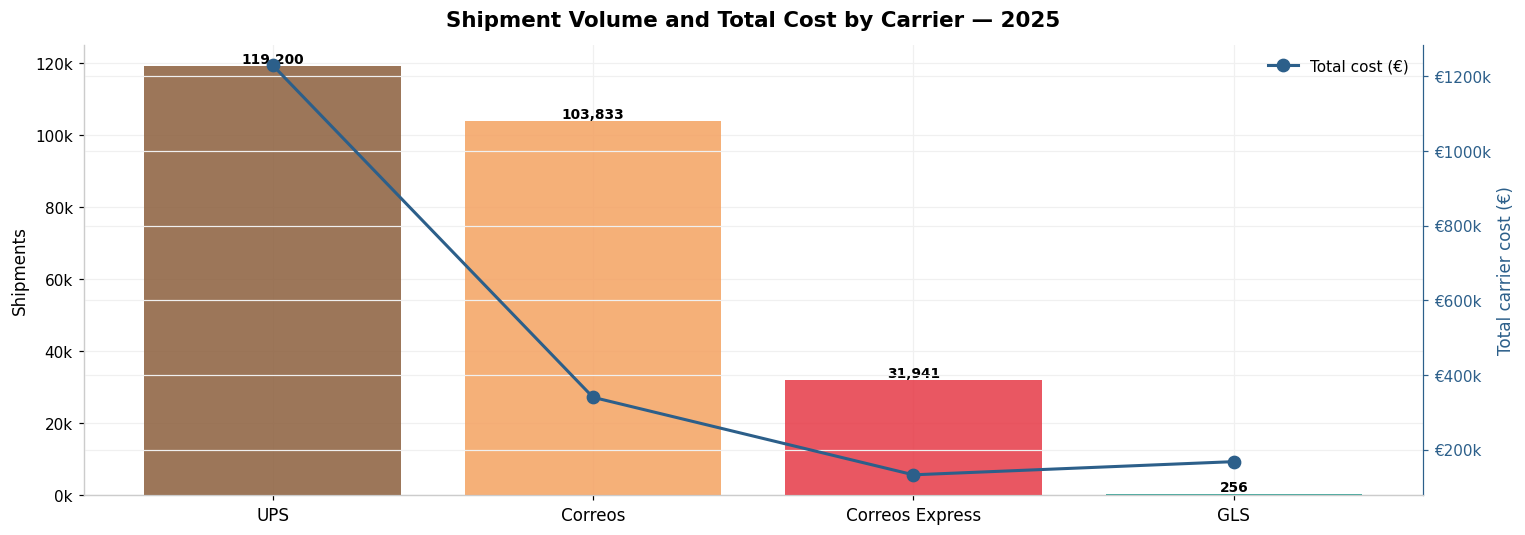

In [11]:
# ── Plot 1: Shipment volume and total cost per carrier ────────────────────────
# Shows the relative size of each carrier in the dataset.
# Left axis = number of shipments, right axis = total carrier cost (€).

carrier_summary = (
    merged.groupby("carrier")
    .agg(shipments=("tracking_id", "count"), total_cost=("carrier_cost_net", "sum"))
    .sort_values("shipments", ascending=False)
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(FIG_W, FIG_H))
ax2 = ax1.twinx()

colors = [CARRIER_COLORS.get(c, PALETTE["neutral"]) for c in carrier_summary["carrier"]]
x = range(len(carrier_summary))

bars = ax1.bar(x, carrier_summary["shipments"], color=colors, alpha=0.85, zorder=3)
ax2.plot(x, carrier_summary["total_cost"], marker="o", color=PALETTE["primary"],
         linewidth=2, markersize=8, zorder=4, label="Total cost (€)")

ax1.set_xticks(list(x))
ax1.set_xticklabels(carrier_summary["carrier"], fontsize=11)
ax1.set_ylabel("Shipments", fontsize=11)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax2.set_ylabel("Total carrier cost (€)", fontsize=11, color=PALETTE["primary"])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1_000:.0f}k"))
ax2.tick_params(axis="y", colors=PALETTE["primary"])
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_color(PALETTE["primary"])

for bar, row in zip(bars, carrier_summary.itertuples()):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
             f"{row.shipments:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax1.set_title("Shipment Volume and Total Cost by Carrier — 2025", pad=12)
ax1.set_xlabel("")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()

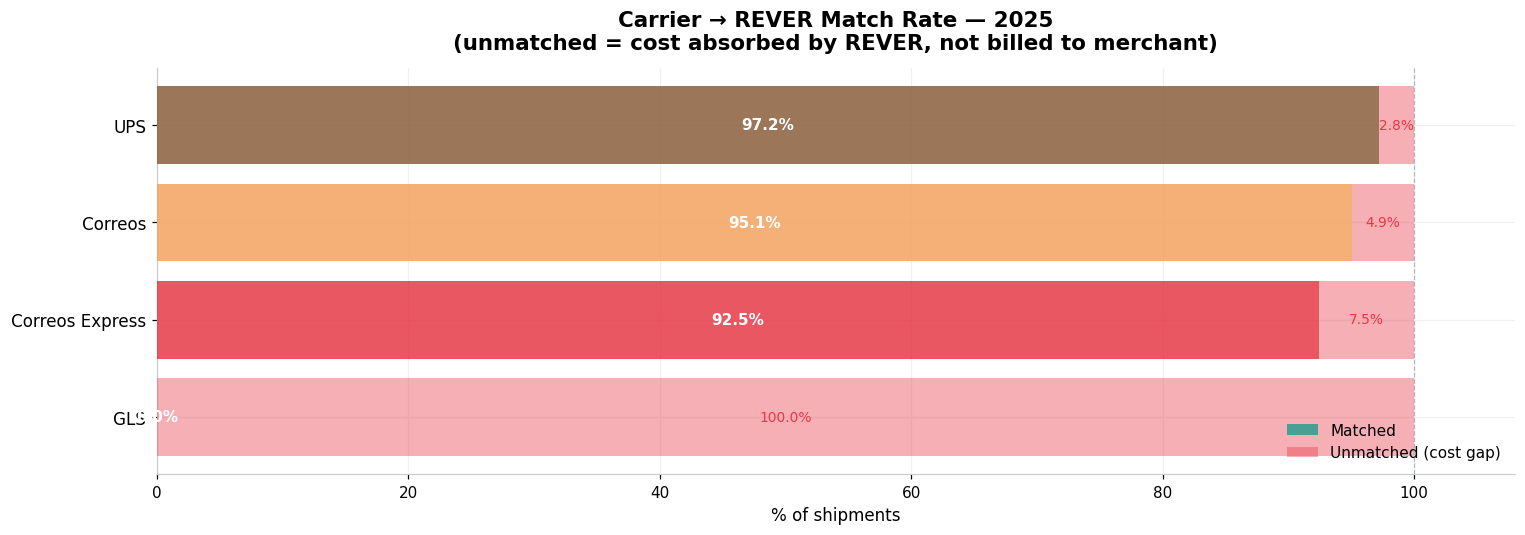

In [12]:
# ── Plot 2: Match rate per carrier (carrier → REVER join quality) ─────────────
# For each carrier, shows % of shipments that matched a REVER invoice row.
# Unmatched = carrier billed REVER but REVER never charged the merchant.
# This is the "cost gap" — a real cost absorbed by REVER.

match_stats = (
    merged.groupby("carrier")
    .apply(lambda g: pd.Series({
        "matched"  : g["rever_revenue_net"].notna().sum(),
        "unmatched": g["rever_revenue_net"].isna().sum(),
        "total"    : len(g),
    }), include_groups=False)
    .reset_index()
)
match_stats["match_pct"]   = match_stats["matched"]   / match_stats["total"] * 100
match_stats["unmatch_pct"] = match_stats["unmatched"] / match_stats["total"] * 100
match_stats = match_stats.sort_values("match_pct", ascending=True)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
y = range(len(match_stats))

ax.barh(y, match_stats["match_pct"],
        color=[CARRIER_COLORS.get(c, PALETTE["neutral"]) for c in match_stats["carrier"]],
        alpha=0.85, label="Matched", zorder=3)
ax.barh(y, match_stats["unmatch_pct"], left=match_stats["match_pct"],
        color=PALETTE["negative"], alpha=0.4, label="Unmatched (cost gap)", zorder=3)

ax.set_yticks(list(y))
ax.set_yticklabels(match_stats["carrier"], fontsize=11)
ax.set_xlabel("% of shipments")
ax.axvline(100, color=PALETTE["neutral"], linewidth=0.8, linestyle="--")
ax.set_xlim(0, 108)

for i, row in enumerate(match_stats.itertuples()):
    ax.text(row.match_pct / 2, i, f"{row.match_pct:.1f}%",
            ha="center", va="center", fontsize=10, fontweight="bold", color="white")
    if row.unmatch_pct > 0.5:
        ax.text(row.match_pct + row.unmatch_pct / 2, i, f"{row.unmatch_pct:.1f}%",
                ha="center", va="center", fontsize=9, color=PALETTE["negative"])

ax.set_title("Carrier → REVER Match Rate — 2025\n(unmatched = cost absorbed by REVER, not billed to merchant)", pad=12)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

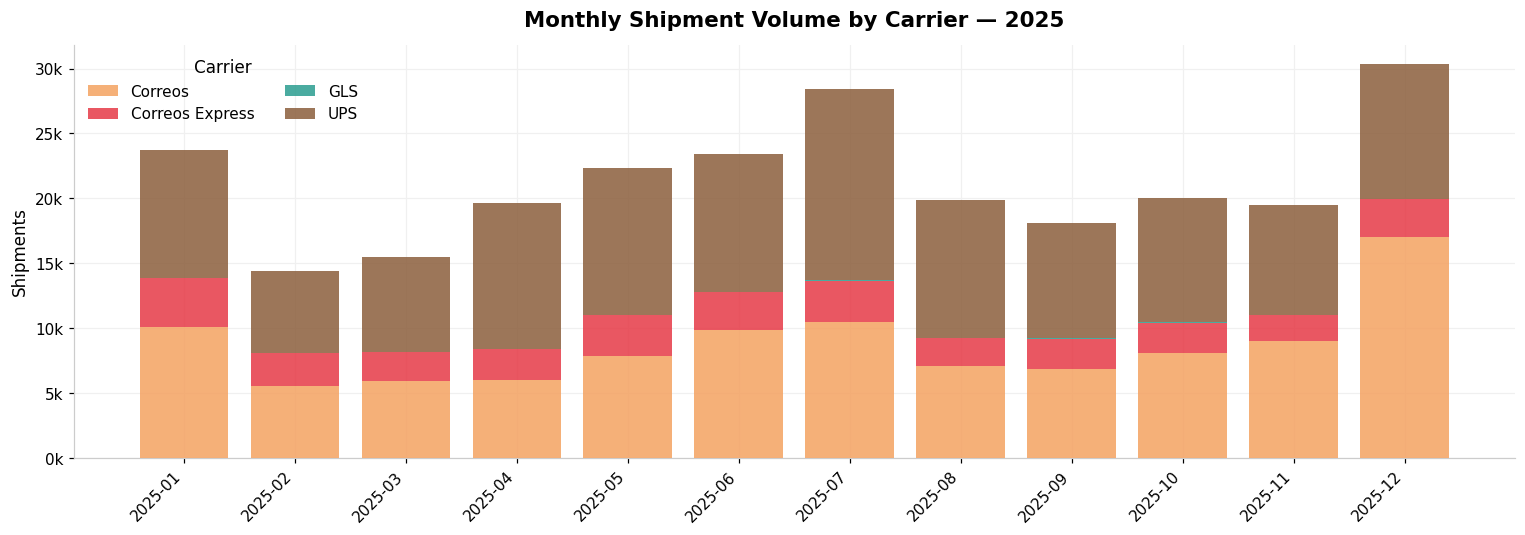

In [13]:
# ── Plot 3: Monthly shipment volume by carrier (stacked bar) ──────────────────
# Shows how shipment volume evolves month by month across carriers.
# Helps identify seasonality and carrier mix changes over 2025.

monthly_vol = (
    merged.groupby(["month", "carrier"])
    .size()
    .reset_index(name="shipments")
    .pivot(index="month", columns="carrier", values="shipments")
    .fillna(0)
    .sort_index()
)

carriers_in_data = monthly_vol.columns.tolist()
bar_colors = [CARRIER_COLORS.get(c, PALETTE["neutral"]) for c in carriers_in_data]

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

bottom = np.zeros(len(monthly_vol))
for carrier_name, color in zip(carriers_in_data, bar_colors):
    vals = monthly_vol[carrier_name].values
    ax.bar(monthly_vol.index, vals, bottom=bottom, label=carrier_name,
           color=color, alpha=0.85, zorder=3)
    bottom += vals

ax.set_xlabel("")
ax.set_ylabel("Shipments")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax.set_xticklabels(monthly_vol.index, rotation=45, ha="right")
ax.legend(title="Carrier", loc="upper left", ncol=2)
ax.set_title("Monthly Shipment Volume by Carrier — 2025", pad=12)
plt.tight_layout()
plt.show()

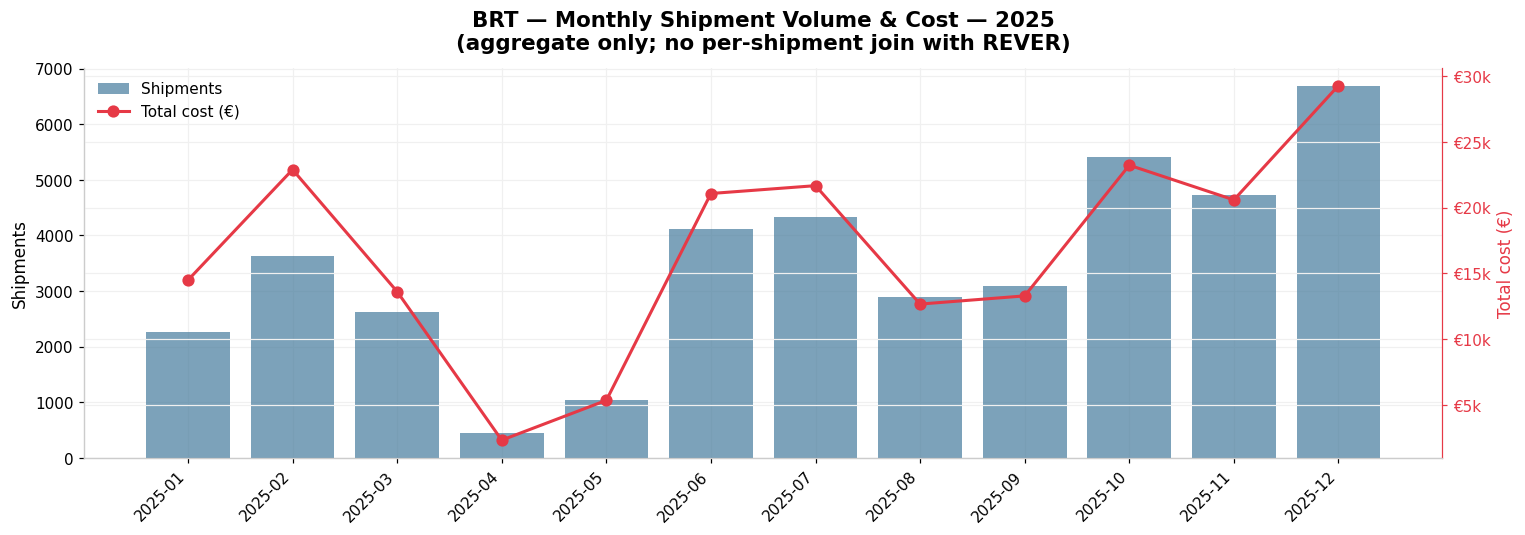

In [14]:
# ── Plot 4: BRT — monthly cost and volume (aggregate only) ────────────────────
# BRT cannot be joined to REVER per shipment. Shown separately for cost visibility.
# Left axis = shipment count, right axis = monthly total cost (€).
# Useful for trend and seasonality analysis of BRT spend.

brt_monthly = (
    brt.groupby("month")
    .agg(shipments=("carrier_cost_net", "count"), total_cost=("carrier_cost_net", "sum"))
    .sort_index()
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(FIG_W, FIG_H))
ax2 = ax1.twinx()

ax1.bar(brt_monthly["month"], brt_monthly["shipments"],
        color=CARRIER_COLORS["BRT"], alpha=0.7, label="Shipments", zorder=3)
ax2.plot(brt_monthly["month"], brt_monthly["total_cost"],
         marker="o", color=PALETTE["negative"], linewidth=2, markersize=7,
         label="Total cost (€)", zorder=4)

ax1.set_xlabel("")
ax1.set_ylabel("Shipments")
ax2.set_ylabel("Total cost (€)", color=PALETTE["negative"])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"€{v/1_000:.0f}k"))
ax2.tick_params(axis="y", colors=PALETTE["negative"])
ax2.spines["right"].set_visible(True)
ax2.spines["right"].set_color(PALETTE["negative"])

ax1.set_xticklabels(brt_monthly["month"], rotation=45, ha="right")
ax1.set_title("BRT — Monthly Shipment Volume & Cost — 2025\n(aggregate only; no per-shipment join with REVER)", pad=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()

---
## Section 4 — Save Processed Data

All cleaned datasets are persisted to `../processed/` as Parquet files for fast loading in downstream notebooks.

| File | Contents |
|---|---|
| `merged.parquet` | Per-shipment join of carrier master + REVER revenue |
| `brt_agg.parquet` | BRT aggregate (no REVER join) |
| `rever.parquet` | REVER invoiced logistics (cleaned) |
| `adj.parquet` | REVER adjustments (cleaned) |

In [15]:
# ── Save all processed datasets ───────────────────────────────────────────────
# Parquet is used for efficient columnar storage and fast loading in downstream notebooks.
# All downstream notebooks (02–08) load from here — do NOT re-parse raw files.

merged.to_parquet(PROCESSED / "merged.parquet", index=False)
brt.to_parquet(   PROCESSED / "brt_agg.parquet", index=False)
rever.to_parquet( PROCESSED / "rever.parquet",   index=False)
adj.to_parquet(   PROCESSED / "adj.parquet",      index=False)

print("Saved to ../processed/")
for f in sorted(PROCESSED.glob("*.parquet")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<25} {size_kb:>7.0f} KB")

Saved to ../processed/
  adj.parquet                  3067 KB
  brt_agg.parquet              2075 KB
  merged.parquet               6128 KB
  rever.parquet               13600 KB
